# ☕ Do Coffee Enthusiasts Actually Taste Coffee Differently?

## An Exploratory and Statistical Analysis of Coffee Preferences

Coffee preference is often treated as a matter of personal taste. However, experience may influence how people evaluate acidity, bitterness, roast characteristics, and overall quality.

This project analyzes survey responses from more than 4,000 coffee drinkers who reported their consumption habits, purchasing behavior, demographics, and coffee expertise. Participants also completed a blind taste test involving four coffees labeled **A, B, C, and D**.

The central research question is:

> **Do people with greater coffee expertise evaluate blind-tasted coffees differently from less experienced coffee drinkers?**

The analysis combines exploratory data analysis, visualization, non-parametric statistical testing, correlation analysis, and consumer behavior analysis.

### Research Questions

1. What does the typical participant's coffee consumption profile look like?
2. Which blind-test coffee is preferred overall?
3. Are the differences between coffee ratings statistically significant?
4. Does coffee expertise influence blind taste preferences?
5. Do experienced drinkers respond differently to acidity and bitterness?
6. Is greater coffee expertise associated with higher coffee spending?

### Dataset

The dataset contains survey responses from over 4,000 participants and includes:

* demographic characteristics
* daily coffee consumption
* favorite coffee drinks
* roast and strength preferences
* brewing and purchasing habits
* self-rated coffee expertise
* monthly coffee spending
* blind taste-test evaluations
* perceived acidity and bitterness
* personal preference scores for Coffees A–D


In [1]:
# Core libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy import stats
from itertools import combinations

# Display settings
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:.3f}")

# Load dataset
file_path = "/kaggle/input/datasets/nalisha/coffee-taste-test-survey-dataset/24_Coffee_Taste_Test.csv"
df = pd.read_csv(file_path)

print(f"Dataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns")

display(df.head())

Dataset shape: 4,042 rows × 57 columns


,submission_id,age,cups,where_drink,brew,brew_other,purchase,purchase_other,favorite,favorite_specify,additions,additions_other,dairy,sweetener,style,strength,roast_level,caffeine,expertise,coffee_a_bitterness,coffee_a_acidity,coffee_a_personal_preference,coffee_a_notes,coffee_b_bitterness,coffee_b_acidity,coffee_b_personal_preference,coffee_b_notes,coffee_c_bitterness,coffee_c_acidity,coffee_c_personal_preference,coffee_c_notes,coffee_d_bitterness,coffee_d_acidity,coffee_d_personal_preference,coffee_d_notes,prefer_abc,prefer_ad,prefer_overall,wfh,total_spend,why_drink,why_drink_other,taste,know_source,most_paid,most_willing,value_cafe,spent_equipment,value_equipment,gender,gender_specify,education_level,ethnicity_race,ethnicity_race_specify,employment_status,number_children,political_affiliation
0,gMR29l,18-24 years old,NaN,NaN,NaN,NaN,NaN,NaN,Regular drip coffee,NaN,No - just black,NaN,NaN,NaN,Complex,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,BkPN0e,25-34 years old,NaN,NaN,Pod/capsule machine (e.g. Keurig/Nespresso),NaN,NaN,NaN,Iced coffee,NaN,"Sugar or sweetener, No - just black",NaN,NaN,NaN,Light,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,W5G8jj,25-34 years old,NaN,NaN,Bean-to-cup machine,NaN,NaN,NaN,Regular drip coffee,NaN,No - just black,NaN,NaN,NaN,Complex,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4xWgGr,35-44 years old,NaN,NaN,Coffee brewing machine (e.g. Mr. Coffee),NaN,NaN,NaN,Iced coffee,NaN,"No - just black, Cinnamon",NaN,NaN,NaN,Complex,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,QD27Q8,25-34 years old,NaN,NaN,Pour over,NaN,NaN,NaN,Latte,NaN,No - just black,NaN,NaN,NaN,Sweet,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 1. Data Quality and Initial Inspection

Before analyzing consumer behavior or taste preferences, the dataset is inspected for:

* dataset dimensions
* duplicate observations
* variable types
* missing values
* potentially conditional survey fields

Missing values require careful interpretation. Some variables are follow-up questions that only apply to certain respondents. Therefore, rows should not automatically be removed simply because they contain missing values.

The goal of this stage is to understand the structure and limitations of the dataset before performing statistical analysis.

In [2]:
# Basic dataset audit

print("DATASET OVERVIEW")
print("=" * 60)

print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")
print(f"Duplicate rows: {df.duplicated().sum():,}")

print("\nCOLUMN DATA TYPES")
print("=" * 60)

dtype_summary = (
    df.dtypes
    .astype(str)
    .value_counts()
    .to_frame("count")
)

display(dtype_summary)

print("\nMISSING VALUES")
print("=" * 60)

missing_summary = (
    df.isna()
      .mean()
      .mul(100)
      .sort_values(ascending=False)
      .to_frame("missing_percent")
)

display(missing_summary.head(20))

DATASET OVERVIEW
Rows: 4,042
Columns: 57
Duplicate rows: 0

COLUMN DATA TYPES


,count
object,44
float64,13



MISSING VALUES


,missing_percent
gender_specify,99.703
purchase_other,99.233
additions_other,98.812
ethnicity_race_specify,97.402
favorite_specify,97.180
why_drink_other,95.868
sweetener,87.333
brew_other,83.226
purchase,82.434
number_children,78.822


### Data Quality Interpretation

The dataset contains both structured survey responses and conditional follow-up fields.

High missingness does not necessarily indicate poor data quality. For example, variables asking respondents to specify an "other" response are expected to be missing for most participants. Free-text tasting notes may also be incomplete because participants were not always required to provide written descriptions.

For this reason, the analysis uses **targeted missing-value handling**:

* relevant observations are retained whenever possible
* missing values are removed only for the specific variables required by each analysis
* the dataset is not reduced using a blanket `dropna()` operation

This approach preserves substantially more information than complete-case deletion across all variables.

## 2. Who Participated in the Survey?

Before examining blind taste preferences, it is useful to understand the survey population.

This section explores:

* participant age
* daily coffee consumption
* favorite coffee drinks
* roast preferences
* preferred coffee strength
* self-rated coffee expertise

These variables provide context for interpreting the later taste-test results.

In [3]:
# Helper plotting functions

def plot_bar(series, title, xlabel, ylabel="Participants", rotation=45):
    counts = series.value_counts(dropna=True)

    plt.figure(figsize=(10, 5))
    counts.plot(kind="bar")

    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.xticks(rotation=rotation, ha="right")
    plt.tight_layout()
    plt.show()


def plot_horizontal_bar(series, title, ylabel, top_n=10):
    counts = (
        series.value_counts(dropna=True)
        .head(top_n)
        .sort_values()
    )

    plt.figure(figsize=(10, 5))
    counts.plot(kind="barh")

    plt.title(title)
    plt.xlabel("Participants")
    plt.ylabel(ylabel)
    plt.tight_layout()
    plt.show()

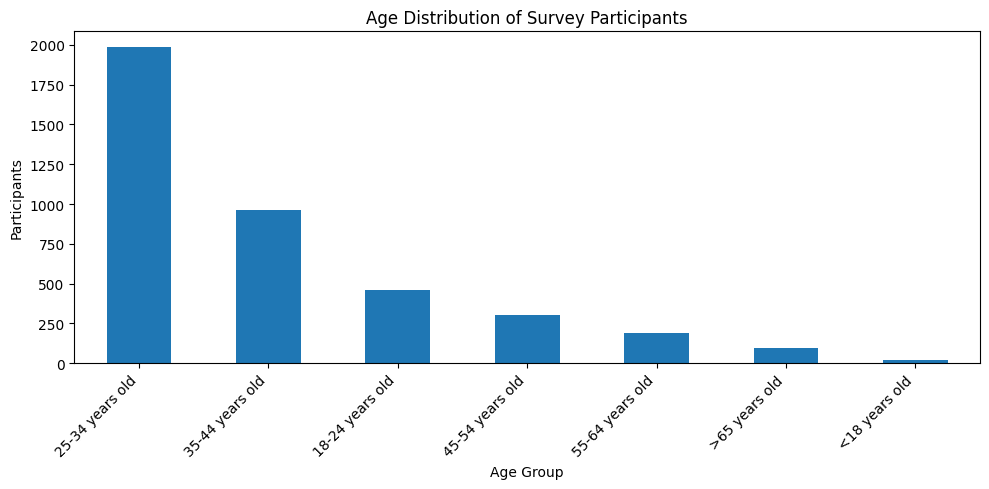

In [4]:
# Participant age distribution

plot_bar(
    df["age"],
    title="Age Distribution of Survey Participants",
    xlabel="Age Group"
)

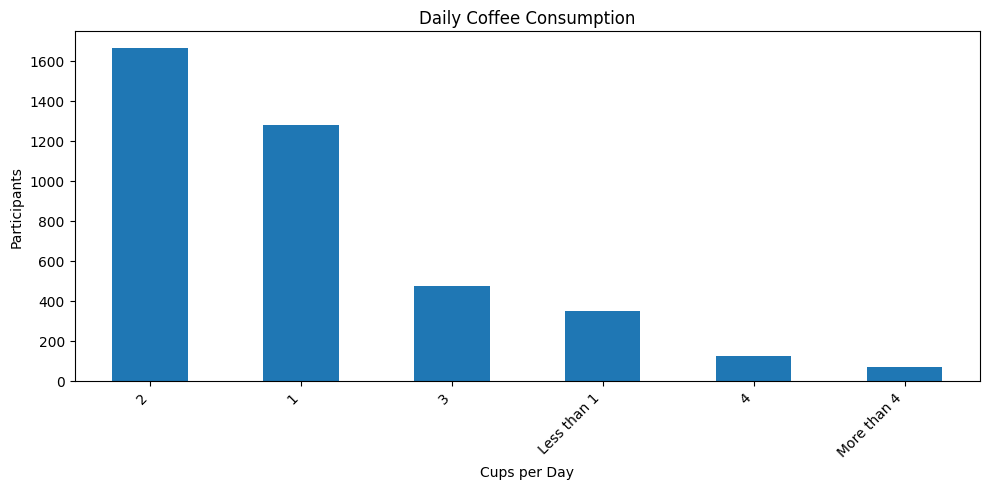

In [5]:
# Daily coffee consumption

plot_bar(
    df["cups"],
    title="Daily Coffee Consumption",
    xlabel="Cups per Day"
)

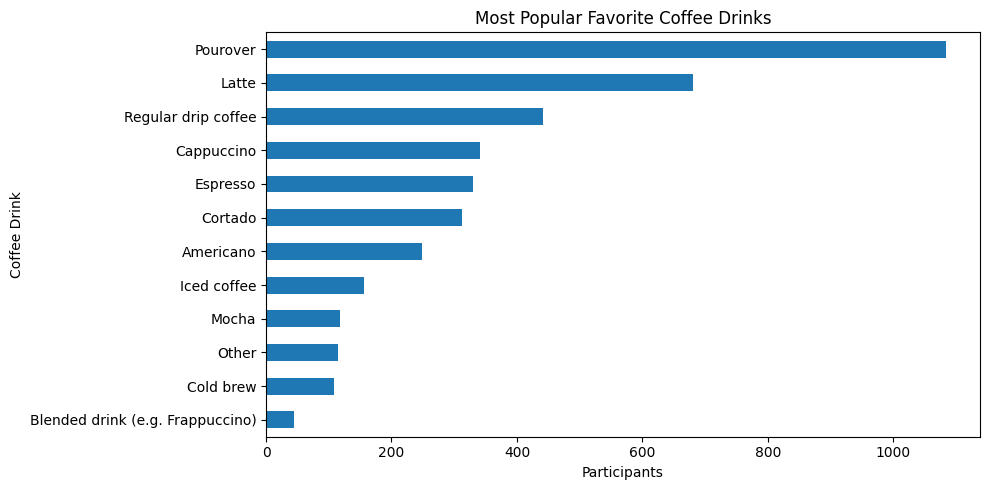

In [6]:
# Most popular coffee drinks

plot_horizontal_bar(
    df["favorite"],
    title="Most Popular Favorite Coffee Drinks",
    ylabel="Coffee Drink",
    top_n=12
)

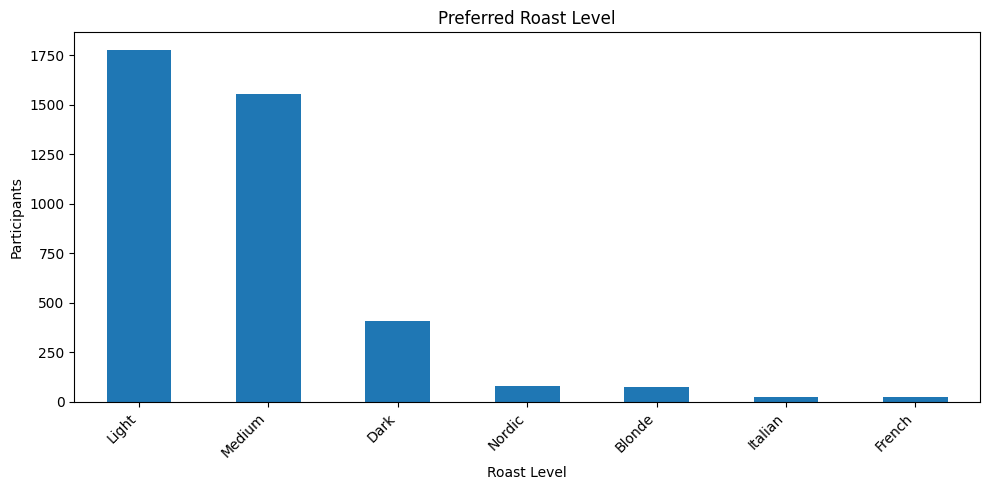

In [7]:
# Roast preference

plot_bar(
    df["roast_level"],
    title="Preferred Roast Level",
    xlabel="Roast Level"
)

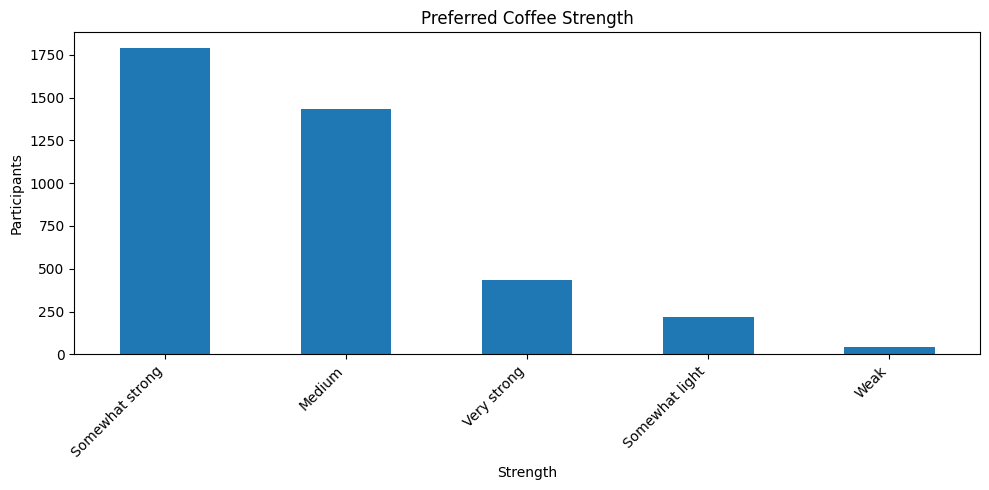

In [8]:
# Coffee strength preference

plot_bar(
    df["strength"],
    title="Preferred Coffee Strength",
    xlabel="Strength"
)

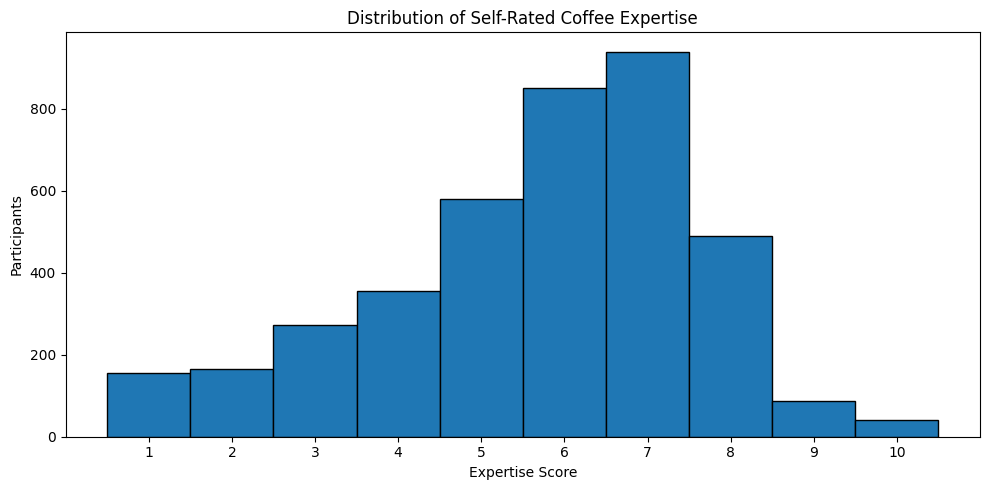

Mean expertise: 5.69
Median expertise: 6.00


In [9]:
# Expertise distribution

plt.figure(figsize=(10, 5))

df["expertise"].dropna().plot(
    kind="hist",
    bins=np.arange(0.5, 11.5, 1),
    edgecolor="black"
)

plt.title("Distribution of Self-Rated Coffee Expertise")
plt.xlabel("Expertise Score")
plt.ylabel("Participants")
plt.xticks(range(1, 11))
plt.tight_layout()
plt.show()

print(f"Mean expertise: {df['expertise'].mean():.2f}")
print(f"Median expertise: {df['expertise'].median():.2f}")

## 3. Blind Taste-Test Results

The central part of the dataset is the blind taste test.

Each participant evaluated four coffees:

* **Coffee A**
* **Coffee B**
* **Coffee C**
* **Coffee D**

For each coffee, the dataset includes measures such as:

* personal preference
* perceived bitterness
* perceived acidity

The first objective is to determine which coffee performed best overall and whether any coffees generated particularly polarized reactions.

In [10]:
# Define taste-test variables

preference_cols = {
    "A": "coffee_a_personal_preference",
    "B": "coffee_b_personal_preference",
    "C": "coffee_c_personal_preference",
    "D": "coffee_d_personal_preference"
}

bitterness_cols = {
    "A": "coffee_a_bitterness",
    "B": "coffee_b_bitterness",
    "C": "coffee_c_bitterness",
    "D": "coffee_d_bitterness"
}

acidity_cols = {
    "A": "coffee_a_acidity",
    "B": "coffee_b_acidity",
    "C": "coffee_c_acidity",
    "D": "coffee_d_acidity"
}

In [11]:
# Overall preference summary

preference_summary = []

for coffee, col in preference_cols.items():

    preference_summary.append({
        "Coffee": coffee,
        "N": df[col].count(),
        "Mean Preference": df[col].mean(),
        "Median Preference": df[col].median(),
        "Standard Deviation": df[col].std(),
        "% Rating 4 or 5": (df[col] >= 4).mean() * 100,
        "% Rating 1 or 2": (df[col] <= 2).mean() * 100
    })

preference_summary = (
    pd.DataFrame(preference_summary)
    .sort_values("Mean Preference", ascending=False)
)

display(preference_summary.round(3))

,Coffee,N,Mean Preference,Median Preference,Standard Deviation,% Rating 4 or 5,% Rating 1 or 2
3,D,3764,3.376,4.000,1.453,50.742,28.723
0,A,3789,3.311,3.000,1.186,46.215,25.111
1,B,3773,3.069,3.000,1.114,33.127,29.812
2,C,3766,3.065,3.000,1.128,33.696,29.713


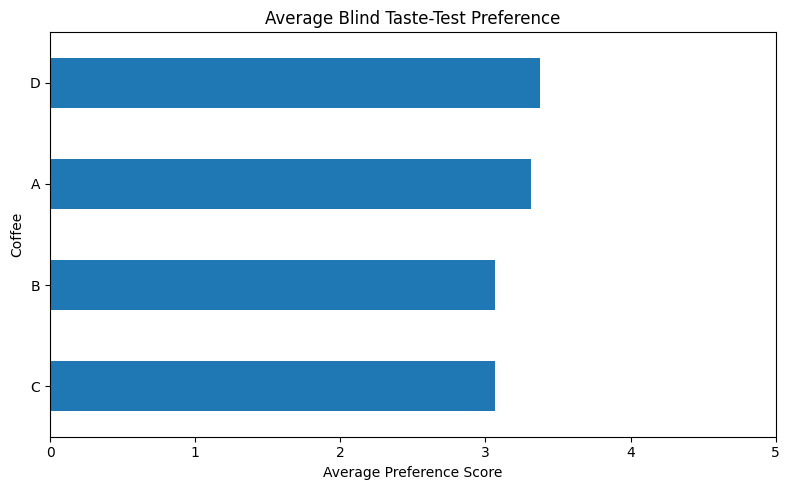

In [12]:
# Mean preference visualization

mean_preferences = (
    preference_summary
    .set_index("Coffee")["Mean Preference"]
    .sort_values()
)

plt.figure(figsize=(8, 5))

mean_preferences.plot(kind="barh")

plt.title("Average Blind Taste-Test Preference")
plt.xlabel("Average Preference Score")
plt.ylabel("Coffee")
plt.xlim(0, 5)
plt.tight_layout()
plt.show()

### Overall Preference Results

Coffee **D** received the highest overall average preference score, with Coffee **A** following closely behind. Coffees **B** and **C** received lower average ratings.

However, average ratings alone do not establish whether the observed differences are statistically meaningful. They also do not reveal whether different types of participants prefer different coffees.

The next stage therefore applies a statistical test that accounts for the repeated-measures structure of the experiment.

## 4. Are Preference Differences Statistically Significant?

The same participants rated multiple coffees. Therefore, the ratings are **paired observations**, not independent groups.

A standard one-way ANOVA would ignore this repeated-measures structure.

Because the preference ratings are ordinal and repeated across the same participants, this analysis uses the **Friedman test**, a non-parametric alternative for comparing multiple related samples.

### Hypotheses

**Null hypothesis (H₀):**

> The distribution of preference ratings is the same across Coffees A, B, C, and D.

**Alternative hypothesis (H₁):**

> At least one coffee has a different preference distribution.


In [13]:
# Friedman test for repeated preference ratings

complete_preferences = df[
    list(preference_cols.values())
].dropna()

friedman_stat, friedman_p = stats.friedmanchisquare(
    complete_preferences[preference_cols["A"]],
    complete_preferences[preference_cols["B"]],
    complete_preferences[preference_cols["C"]],
    complete_preferences[preference_cols["D"]]
)

print("FRIEDMAN TEST")
print("=" * 60)

print(f"Complete participants: {len(complete_preferences):,}")
print(f"Chi-square statistic: {friedman_stat:.3f}")
print(f"p-value: {friedman_p:.6g}")

if friedman_p < 0.001:
    print("\nConclusion: Preference differs significantly across coffees (p < 0.001).")
elif friedman_p < 0.05:
    print("\nConclusion: Preference differs significantly across coffees (p < 0.05).")
else:
    print("\nConclusion: No statistically significant difference was detected.")

FRIEDMAN TEST
Complete participants: 3,744
Chi-square statistic: 196.886
p-value: 1.98581e-42

Conclusion: Preference differs significantly across coffees (p < 0.001).


### Friedman Test Interpretation

The Friedman test indicates a statistically significant difference in preference ratings across the four coffees (**p < 0.001**).

This provides strong evidence against the null hypothesis that all four coffees received equivalent preference ratings.

However, the Friedman test is an omnibus test. It shows that a difference exists somewhere among the four coffees, but it does not identify which specific pairs differ.

Pairwise post-hoc testing is therefore required.


## 5. Which Coffees Differ From Each Other?

Pairwise **Wilcoxon signed-rank tests** are used because the coffee ratings are paired observations from the same participants.

Six pairwise comparisons are performed:

* A vs B
* A vs C
* A vs D
* B vs C
* B vs D
* C vs D

Because multiple tests increase the probability of false-positive findings, a **Bonferroni correction** is applied to the p-values.


In [14]:
# Pairwise Wilcoxon signed-rank tests
# with Bonferroni correction

pairwise_results = []

coffee_pairs = list(combinations(preference_cols.keys(), 2))
n_comparisons = len(coffee_pairs)

for coffee_1, coffee_2 in coffee_pairs:

    pair_data = df[
        [
            preference_cols[coffee_1],
            preference_cols[coffee_2]
        ]
    ].dropna()

    statistic, p_value = stats.wilcoxon(
        pair_data[preference_cols[coffee_1]],
        pair_data[preference_cols[coffee_2]]
    )

    corrected_p = min(p_value * n_comparisons, 1.0)

    pairwise_results.append({
        "Coffee 1": coffee_1,
        "Coffee 2": coffee_2,
        "N": len(pair_data),
        "Mean 1": pair_data[preference_cols[coffee_1]].mean(),
        "Mean 2": pair_data[preference_cols[coffee_2]].mean(),
        "Mean Difference": (
            pair_data[preference_cols[coffee_1]].mean()
            - pair_data[preference_cols[coffee_2]].mean()
        ),
        "Raw p-value": p_value,
        "Bonferroni p-value": corrected_p,
        "Significant": corrected_p < 0.05
    })

pairwise_df = pd.DataFrame(pairwise_results)

display(
    pairwise_df.round({
        "Mean 1": 3,
        "Mean 2": 3,
        "Mean Difference": 3,
        "Raw p-value": 6,
        "Bonferroni p-value": 6
    })
)

,Coffee 1,Coffee 2,N,Mean 1,Mean 2,Mean Difference,Raw p-value,Bonferroni p-value,Significant
0,A,B,3763,3.307,3.071,0.236,0.000,0.000,True
1,A,C,3758,3.309,3.065,0.244,0.000,0.000,True
2,A,D,3756,3.309,3.373,-0.064,0.013,0.078,False
3,B,C,3758,3.070,3.065,0.005,0.928,1.000,False
4,B,D,3755,3.068,3.374,-0.306,0.000,0.000,True
5,C,D,3757,3.062,3.375,-0.312,0.000,0.000,True


### Pairwise Comparison Interpretation

The post-hoc analysis adds important nuance to the overall Friedman result.

Although the four coffees differ collectively, not every pair is statistically distinguishable after correction for multiple comparisons.

In particular:

* Coffees **B and C** do not show a meaningful difference after correction.
* Coffees **A and D** are also not significantly different after Bonferroni correction.
* The broader pattern separates the relatively higher-rated **A/D** coffees from the relatively lower-rated **B/C** coffees.

This suggests that the taste test may contain two broader preference profiles rather than a simple ranking in which every coffee is clearly different from every other coffee.


## 6. Does Coffee Expertise Change Blind Taste Preference?

The most important question in this project is whether experienced coffee drinkers evaluate the coffees differently.

Participants are divided into three groups based on self-rated expertise:

* **Beginner:** expertise scores 1–3
* **Intermediate:** expertise scores 4–6
* **Expert:** expertise scores 7–10

The objective is not simply to test whether experts give higher ratings. Instead, the analysis asks whether expertise changes **which coffees people prefer**.


In [15]:
# Create expertise groups

analysis_df = df[
    ["expertise"] + list(preference_cols.values())
].copy()

analysis_df["expertise_group"] = pd.cut(
    analysis_df["expertise"],
    bins=[0, 3, 6, 10],
    labels=["Beginner", "Intermediate", "Expert"],
    include_lowest=True
)

expertise_group_sizes = (
    analysis_df["expertise_group"]
    .value_counts()
    .sort_index()
    .to_frame("Participants")
)

display(expertise_group_sizes)

,Participants
expertise_group,
Beginner,594
Intermediate,1787
Expert,1557


In [16]:
# Average coffee preference by expertise group

expertise_means = (
    analysis_df
    .groupby("expertise_group", observed=True)[
        list(preference_cols.values())
    ]
    .mean()
)

expertise_means.columns = [
    "Coffee A",
    "Coffee B",
    "Coffee C",
    "Coffee D"
]

display(expertise_means.round(3))

,Coffee A,Coffee B,Coffee C,Coffee D
expertise_group,,,,
Beginner,2.824,3.224,3.159,2.661
Intermediate,3.278,3.164,3.160,3.250
Expert,3.539,2.897,2.920,3.795


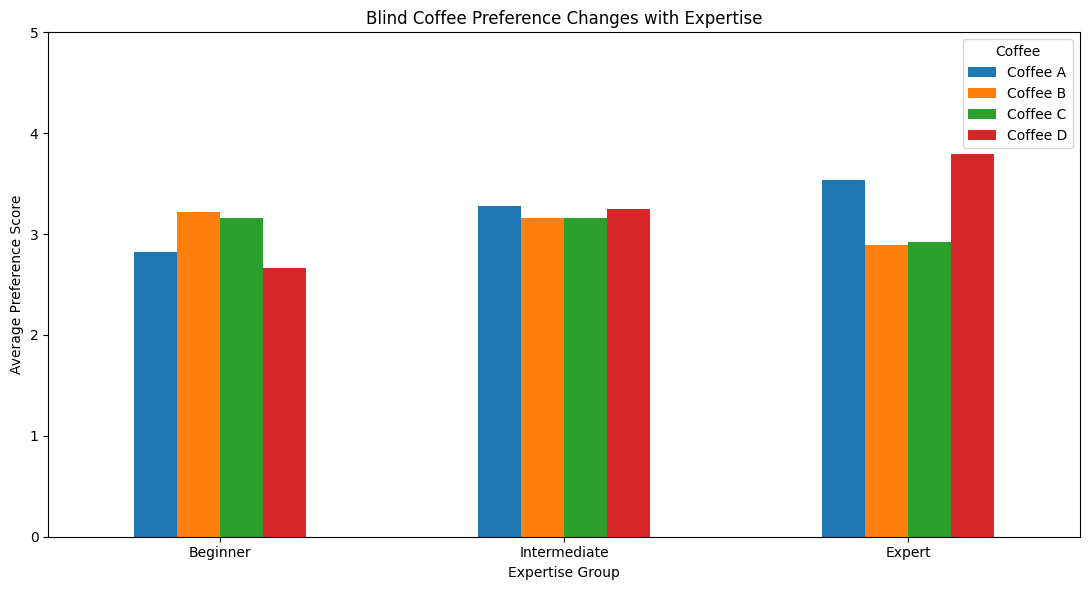

In [17]:
# Visualize preference by expertise group

expertise_means.plot(
    kind="bar",
    figsize=(11, 6)
)

plt.title("Blind Coffee Preference Changes with Expertise")
plt.xlabel("Expertise Group")
plt.ylabel("Average Preference Score")
plt.xticks(rotation=0)
plt.ylim(0, 5)
plt.legend(title="Coffee")
plt.tight_layout()
plt.show()

### Expertise Group Interpretation

This is the central finding of the analysis.

The pattern does **not** suggest that experts simply give higher ratings to every coffee. Instead, expertise is associated with a substantial change in **which coffees are preferred**.

Among beginners:

* Coffee **B** receives the highest average preference score.
* Coffee **D** receives the lowest average preference score.

Among experts:

* Coffee **D** receives the highest average preference score.
* Coffee **B** receives the lowest average preference score.

The reversal is especially notable for Coffee D. Its average preference rises from approximately **2.66 among beginners** to approximately **3.80 among experts**.

Coffee A also becomes more popular as expertise increases, rising from approximately **2.82 among beginners** to approximately **3.54 among experts**.

These findings suggest a genuine preference shift rather than general rating inflation.


## 7. Does the Pattern Persist Across Exact Expertise Scores?

Grouping participants into beginner, intermediate, and expert categories makes the results easy to interpret, but grouping can hide variation.

The next analysis therefore examines average coffee preference across the original **1–10 expertise scale**.

If the relationship is meaningful, systematic trends should remain visible without relying entirely on the three broad expertise categories.


,Coffee A,Coffee B,Coffee C,Coffee D
expertise,,,,
1.000,2.689,3.026,3.007,2.523
2.000,2.857,3.300,3.126,2.656
3.000,2.882,3.291,3.268,2.743
4.000,3.073,3.199,3.167,2.912
5.000,3.231,3.151,3.152,3.130
6.000,3.397,3.158,3.163,3.473
7.000,3.519,2.967,2.983,3.686
8.000,3.576,2.844,2.850,3.920
9.000,3.602,2.578,2.780,4.134


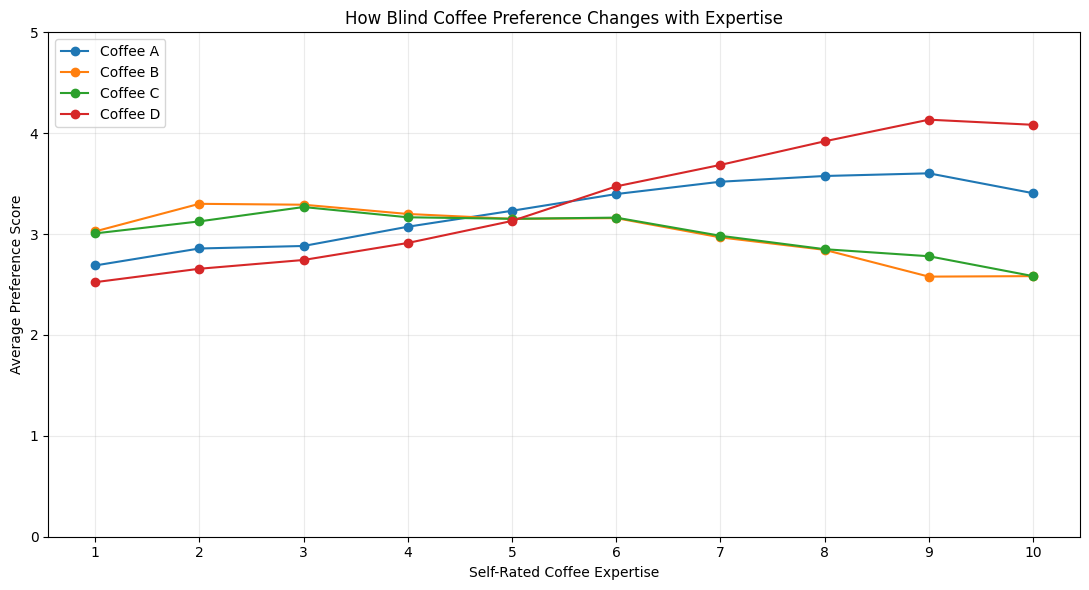

In [18]:
# Preference across exact expertise scores

expertise_trend = (
    df.groupby("expertise")[
        list(preference_cols.values())
    ]
    .mean()
)

expertise_trend.columns = [
    "Coffee A",
    "Coffee B",
    "Coffee C",
    "Coffee D"
]

display(expertise_trend.round(3))

plt.figure(figsize=(11, 6))

for coffee in expertise_trend.columns:
    plt.plot(
        expertise_trend.index,
        expertise_trend[coffee],
        marker="o",
        label=coffee
    )

plt.title("How Blind Coffee Preference Changes with Expertise")
plt.xlabel("Self-Rated Coffee Expertise")
plt.ylabel("Average Preference Score")
plt.xticks(range(1, 11))
plt.ylim(0, 5)
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## 8. Measuring the Expertise–Preference Relationship

Visual trends are useful, but they should be supported by statistical analysis.

Because both expertise and preference ratings are ordinal, **Spearman rank correlation** is used.

Spearman's correlation measures whether higher expertise tends to be associated with systematically higher or lower preference ratings without assuming a linear relationship or normally distributed variables.

The analysis calculates a separate correlation for each coffee.


In [19]:
# Spearman correlations:
# expertise vs preference for each coffee

correlation_results = []

for coffee, col in preference_cols.items():

    temp = df[["expertise", col]].dropna()

    rho, p_value = stats.spearmanr(
        temp["expertise"],
        temp[col]
    )

    correlation_results.append({
        "Coffee": coffee,
        "N": len(temp),
        "Spearman rho": rho,
        "p-value": p_value,
        "Significant": p_value < 0.05
    })

correlation_df = pd.DataFrame(correlation_results)

display(correlation_df.round(4))

,Coffee,N,Spearman rho,p-value,Significant
0,A,3781,0.204,0.000,True
1,B,3766,-0.126,0.000,True
2,C,3762,-0.097,0.000,True
3,D,3760,0.295,0.000,True


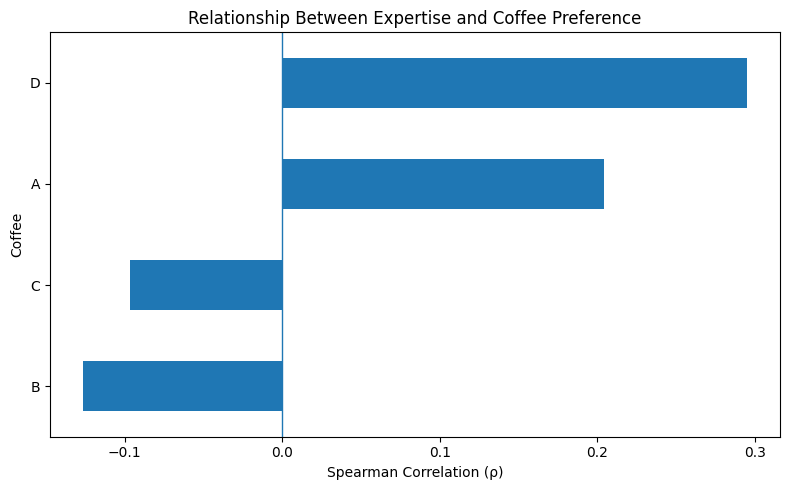

In [20]:
# Visualize expertise-preference correlations

corr_plot = (
    correlation_df
    .set_index("Coffee")["Spearman rho"]
    .sort_values()
)

plt.figure(figsize=(8, 5))

corr_plot.plot(kind="barh")

plt.axvline(0, linewidth=1)

plt.title("Relationship Between Expertise and Coffee Preference")
plt.xlabel("Spearman Correlation (ρ)")
plt.ylabel("Coffee")
plt.tight_layout()
plt.show()

### Correlation Interpretation

The correlation results reinforce the expertise-group analysis.

The strongest relationship appears for **Coffee D**, where expertise is positively associated with preference:

> **Spearman ρ ≈ 0.295**

Coffee A also shows a positive relationship with expertise.

In contrast, Coffees B and C show negative relationships with expertise, meaning that higher-expertise participants tend to rate them less favorably.

This is an important result because the direction of the relationships differs across coffees. Expertise is not associated with universally higher ratings. Instead, greater expertise appears to shift preference toward particular coffees, especially Coffee D.


## 9. Are Expertise-Group Differences Statistically Significant?

The descriptive results show that beginners, intermediates, and experts rate the coffees differently.

To test these differences statistically, a **Kruskal–Wallis test** is performed separately for each coffee.

This non-parametric test is appropriate because:

* preference ratings are ordinal
* expertise groups are independent
* normality is not required

The test evaluates whether the rating distributions differ across beginner, intermediate, and expert participants.


In [21]:
# Kruskal-Wallis tests by coffee

expertise_test_results = []

for coffee, col in preference_cols.items():

    temp = analysis_df[
        ["expertise_group", col]
    ].dropna()

    beginner = temp.loc[
        temp["expertise_group"] == "Beginner",
        col
    ]

    intermediate = temp.loc[
        temp["expertise_group"] == "Intermediate",
        col
    ]

    expert = temp.loc[
        temp["expertise_group"] == "Expert",
        col
    ]

    h_stat, p_value = stats.kruskal(
        beginner,
        intermediate,
        expert
    )

    expertise_test_results.append({
        "Coffee": coffee,
        "H statistic": h_stat,
        "p-value": p_value,
        "Significant": p_value < 0.05
    })

expertise_test_df = pd.DataFrame(expertise_test_results)

display(expertise_test_df.round(6))

,Coffee,H statistic,p-value,Significant
0,A,153.168,0.000,True
1,B,59.747,0.000,True
2,C,40.297,0.000,True
3,D,272.466,0.000,True


## 10. What Sensory Characteristics Distinguish the Coffees?

The expertise effect raises a deeper question:

> **Why might experienced coffee drinkers prefer different coffees?**

To explore this question, the analysis compares three average ratings for each coffee:

* overall preference
* perceived bitterness
* perceived acidity

This does not establish a causal explanation, but it can identify sensory patterns that may help explain the preference shift.


,Preference,Bitterness,Acidity
A,3.311,2.141,3.635
B,3.069,3.013,2.224
C,3.065,3.072,2.367
D,3.376,2.163,3.858


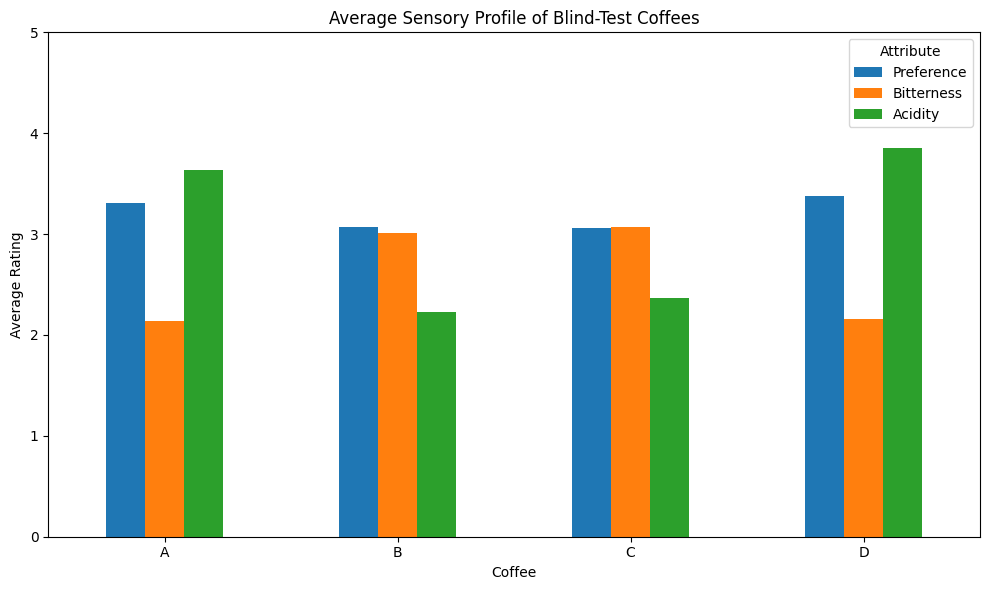

In [22]:
# Average sensory profile of each coffee

coffee_profile = pd.DataFrame({
    "Preference": {
        coffee: df[col].mean()
        for coffee, col in preference_cols.items()
    },
    "Bitterness": {
        coffee: df[col].mean()
        for coffee, col in bitterness_cols.items()
    },
    "Acidity": {
        coffee: df[col].mean()
        for coffee, col in acidity_cols.items()
    }
})

display(coffee_profile.round(3))

coffee_profile.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Average Sensory Profile of Blind-Test Coffees")
plt.xlabel("Coffee")
plt.ylabel("Average Rating")
plt.xticks(rotation=0)
plt.ylim(0, 5)
plt.legend(title="Attribute")
plt.tight_layout()
plt.show()

### Sensory Profile Interpretation

The sensory profiles reveal a notable pattern.

Coffees **A and D**, which become more popular as expertise increases, are characterized by relatively stronger acidity profiles.

Coffees **B and C**, which become less preferred as expertise increases, are relatively more bitter and less acidic.

This pattern suggests a plausible interpretation:

> More experienced coffee drinkers may develop greater preference for brighter or more acidic sensory profiles, while moving away from coffees perceived as more strongly bitter.

However, this should be treated as an **interpretive hypothesis rather than a causal conclusion**. The observational survey design cannot prove that expertise itself causes participants to prefer acidity.


## 11. Does Expertise Affect Perceived Acidity and Bitterness?

A further distinction is important.

Experienced participants may:

1. **perceive** acidity and bitterness differently, or
2. perceive similar characteristics but **value them differently**

To investigate this issue, Spearman correlations are calculated between expertise and perceived acidity and bitterness for each coffee.


In [23]:
# Expertise vs perceived acidity

acidity_expertise_results = []

for coffee, col in acidity_cols.items():

    temp = df[["expertise", col]].dropna()

    rho, p_value = stats.spearmanr(
        temp["expertise"],
        temp[col]
    )

    acidity_expertise_results.append({
        "Coffee": coffee,
        "Spearman rho": rho,
        "p-value": p_value,
        "Significant": p_value < 0.05
    })

acidity_expertise_df = pd.DataFrame(acidity_expertise_results)

print("EXPERTISE VS PERCEIVED ACIDITY")
display(acidity_expertise_df.round(4))

EXPERTISE VS PERCEIVED ACIDITY


,Coffee,Spearman rho,p-value,Significant
0,A,0.049,0.003,True
1,B,-0.066,0.000,True
2,C,-0.091,0.000,True
3,D,0.026,0.113,False


In [24]:
# Expertise vs perceived bitterness

bitterness_expertise_results = []

for coffee, col in bitterness_cols.items():

    temp = df[["expertise", col]].dropna()

    rho, p_value = stats.spearmanr(
        temp["expertise"],
        temp[col]
    )

    bitterness_expertise_results.append({
        "Coffee": coffee,
        "Spearman rho": rho,
        "p-value": p_value,
        "Significant": p_value < 0.05
    })

bitterness_expertise_df = pd.DataFrame(bitterness_expertise_results)

print("EXPERTISE VS PERCEIVED BITTERNESS")
display(bitterness_expertise_df.round(4))

EXPERTISE VS PERCEIVED BITTERNESS


,Coffee,Spearman rho,p-value,Significant
0,A,-0.089,0.000,True
1,B,0.057,0.000,True
2,C,0.076,0.000,True
3,D,-0.143,0.000,True


## 12. Is Coffee Expertise Associated With Higher Spending?

Coffee expertise may influence more than taste.

More experienced consumers may also:

* purchase more specialty coffee
* invest more in brewing equipment
* visit coffee shops more frequently
* spend more on coffee overall

Monthly spending is recorded as ordered categories rather than a continuous numerical variable. Therefore, the categories are converted into an **ordinal spending score**.

Spearman correlation is then used to test whether higher expertise is associated with higher spending categories.


In [25]:
# Inspect spending categories before encoding

print("Observed spending categories:")

display(
    df["total_spend"]
    .value_counts(dropna=False)
    .to_frame("count")
)

Observed spending categories:


,count
total_spend,
$20-$40,1293
$40-$60,1050
NaN,531
<$20,427
$60-$80,387
$80-$100,223
>$100,131


In [26]:
# Encode monthly spending as an ordered score

spend_score_map = {
    "<$20": 1,
    "$20-$40": 2,
    "$40-$60": 3,
    "$60-$80": 4,
    "$80-$100": 5,
    ">$100": 6
}

df["spend_score"] = df["total_spend"].map(spend_score_map)

spend_analysis = df[
    ["expertise", "total_spend", "spend_score"]
].dropna()

spend_rho, spend_p = stats.spearmanr(
    spend_analysis["expertise"],
    spend_analysis["spend_score"]
)

print("EXPERTISE VS MONTHLY COFFEE SPENDING")
print("=" * 60)

print(f"N: {len(spend_analysis):,}")
print(f"Spearman rho: {spend_rho:.3f}")
print(f"p-value: {spend_p:.6g}")

if spend_p < 0.001:
    print("\nConclusion: Expertise is significantly associated with higher spending (p < 0.001).")
elif spend_p < 0.05:
    print("\nConclusion: Expertise is significantly associated with spending (p < 0.05).")
else:
    print("\nConclusion: No significant relationship was detected.")

EXPERTISE VS MONTHLY COFFEE SPENDING
N: 3,511
Spearman rho: 0.298
p-value: 8.47034e-73

Conclusion: Expertise is significantly associated with higher spending (p < 0.001).


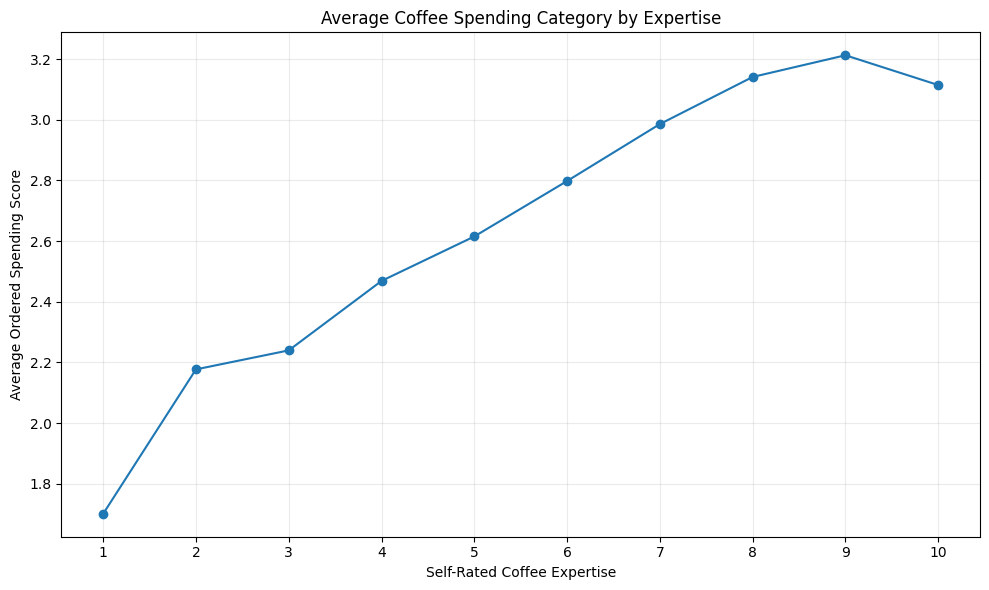

In [27]:
# Visualize spending trend by expertise

spend_by_expertise = (
    spend_analysis
    .groupby("expertise")["spend_score"]
    .mean()
)

plt.figure(figsize=(10, 6))

plt.plot(
    spend_by_expertise.index,
    spend_by_expertise.values,
    marker="o"
)

plt.title("Average Coffee Spending Category by Expertise")
plt.xlabel("Self-Rated Coffee Expertise")
plt.ylabel("Average Ordered Spending Score")
plt.xticks(range(1, 11))
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

### Spending Interpretation

Coffee expertise is positively associated with monthly coffee spending:

> **Spearman ρ ≈ 0.298, p < 0.001**

This represents a moderate positive relationship in the context of consumer survey data.

Participants with greater self-rated coffee expertise tend to fall into higher monthly spending categories.

The result complements the taste-test findings. More experienced coffee drinkers appear to differ from beginners in two ways:

* they show different blind taste preferences
* they tend to spend more money on coffee

This suggests that coffee expertise may reflect broader consumer involvement rather than taste preference alone.


## 13. Key Findings

The analysis produces several important findings.

### 1. Coffee D performs best overall

Coffee D has the highest overall mean preference score at approximately **3.38**, followed closely by Coffee A.

However, Coffee D is also the most polarizing coffee, with the largest standard deviation in preference ratings.

### 2. The four coffees are not rated equally

The Friedman test finds statistically significant differences in preference across the four coffees:

> **p < 0.001**

This confirms that the observed rating differences are unlikely to be explained by random variation alone.

### 3. Not every coffee pair differs

Post-hoc Wilcoxon tests with Bonferroni correction show that:

* A and D are not significantly different from one another
* B and C are not significantly different from one another

This suggests a broader separation between the A/D and B/C preference profiles.

### 4. Expertise strongly changes which coffee people prefer

This is the central finding.

Beginners prefer Coffee B and rate Coffee D lowest.

Experts show the opposite pattern:

* Coffee D becomes the highest-rated coffee
* Coffee B becomes the lowest-rated coffee

Coffee D rises from approximately **2.66 among beginners** to approximately **3.80 among experts**.

### 5. Coffee D has the strongest expertise relationship

The strongest expertise–preference relationship occurs for Coffee D:

> **Spearman ρ ≈ 0.295**

Coffee A also becomes more popular with expertise, while Coffees B and C show negative relationships.

### 6. Sensory profiles may help explain the shift

Coffees A and D are relatively more acidic, while Coffees B and C are relatively more bitter.

This creates a plausible hypothesis that experienced drinkers may develop stronger preferences for brighter, more acidic coffee profiles.

### 7. Expertise is associated with higher spending

Higher expertise is positively associated with higher monthly coffee spending:

> **Spearman ρ ≈ 0.298, p < 0.001**

More experienced coffee drinkers therefore differ not only in taste preferences but also in consumer behavior.


## 14. Conclusion

This project asked:

> **Do coffee enthusiasts actually taste coffee differently?**

The evidence suggests that they do — or, more precisely, that they **evaluate blind-tasted coffees differently**.

The results do not show that experienced coffee drinkers simply assign higher scores to every coffee. Instead, expertise is associated with a systematic shift in preference.

Beginners tend to prefer Coffee B, while experts strongly favor Coffee D. Coffee A also becomes more popular with increasing expertise, whereas Coffees B and C become less preferred.

The sensory analysis provides a possible explanation. Coffees A and D have relatively stronger acidity profiles, while B and C are relatively more bitter. This suggests that experienced coffee drinkers may develop greater appreciation for brighter and more acidic coffees.

The consumer behavior analysis adds another dimension. Greater expertise is also associated with higher monthly coffee spending, indicating that coffee expertise may reflect deeper involvement in coffee as both a sensory experience and a consumer category.

Overall, the findings support the conclusion that:

> **Coffee expertise is associated with meaningful differences in blind taste preference, sensory evaluation, and spending behavior.**


## 15. Limitations

Several limitations should be considered when interpreting the results.

### Self-reported expertise

Coffee expertise is based on participants' own ratings. A person who identifies as an expert may not necessarily have formal sensory training or professional coffee experience.

### Observational design

The analysis identifies associations, not causal effects. It cannot prove that becoming more knowledgeable about coffee causes a person to prefer Coffee D or spend more money.

### Unequal expertise groups

The beginner, intermediate, and expert groups may differ substantially in size. Estimates for smaller groups may therefore be less stable.

### Ordinal rating scales

Preference, acidity, bitterness, and expertise are measured using ordered rating scales. The analysis therefore emphasizes non-parametric methods such as Friedman, Wilcoxon, Kruskal–Wallis, and Spearman tests.

### Multiple comparisons

Pairwise testing increases the risk of false-positive findings. Bonferroni correction was used to reduce this risk, although conservative corrections can also reduce statistical power.

### Unobserved confounding

Variables such as age, income, education, brewing method, and purchasing habits may be related to both expertise and taste preference. Future analysis could use multivariable models to investigate whether the expertise relationship remains after controlling for these factors.

Despite these limitations, the dataset provides strong evidence of systematic differences in blind coffee preference across expertise levels.


## 16. Possible Next Steps

This analysis could be extended in several directions.

### Multivariable modeling

Test whether expertise predicts coffee preference after controlling for:

* age
* gender
* income
* education
* daily coffee consumption
* roast preference
* brewing method

### Preference prediction

Build a machine learning model to predict:

* preferred blind-test coffee
* high-spending consumers
* high-expertise participants

### Consumer segmentation

Use clustering methods to identify groups such as:

* casual coffee drinkers
* convenience-focused consumers
* specialty coffee enthusiasts
* high-spending equipment users

### Text analysis

The free-text tasting notes could be analyzed using natural language processing to determine whether experienced participants use:

* more specific sensory vocabulary
* more diverse tasting descriptors
* different acidity or bitterness terminology

### Robustness analysis

Alternative expertise thresholds could be tested to determine whether the beginner–expert preference reversal remains stable under different group definitions.
